<a href="https://colab.research.google.com/github/mevalle/MPCL-CCP/blob/main/Experiment_Synthetic_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Info:

This notebook ilustrates the application of the MPCL-CCP for a synthetic dataset. For comparison purposes, the notebook also illustrates the application of the other strategies for training the MPCL network, including MPCL-Greedy, MPCL-Adam, and MPCL-DCCP, as detailed in the paper.

# Import libraries

Import the necessary libraries.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
import time

In [ ]:
# Download MPCL.py from the GitHub repository
!wget -O MPCL.py https://raw.githubusercontent.com/mevalle/MPCL-CCP/master/MPCL.py
print('MPCL.py downloaded successfully!')

!pip install dccp

--2026-04-26 20:03:02--  https://raw.githubusercontent.com/mevalle/MPCL-CCP/master/MPCL.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30553 (30K) [text/plain]
Saving to: ‘MPCL.py’

MPCL.py             100%[===================>]  29.84K  --.-KB/s    in 0.002s  

2026-04-26 20:03:02 (13.9 MB/s) - ‘MPCL.py’ saved [30553/30553]

MPCL.py downloaded successfully!


In [ ]:
from MPCL import MPCL_CCP, MPCL_Adam, MPCL_DCCP, MPCL_Greedy

In [ ]:
import warnings

# Suppress FutureWarning from cvxpy
warnings.filterwarnings("ignore", category=FutureWarning, module='cvxpy')


# Example

In [ ]:
K = 4
Nclass = 3
X,y = make_blobs(n_samples=K*Nclass*100,n_features=2,centers = Nclass*K, cluster_std=1.5, random_state=42)
y = y%Nclass

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=1/3, random_state=42)

# MPCL trained using CCP

The proposed method implemented using SCIPY.

In [ ]:
start_time_class = time.time()
clf = MPCL_CCP(K=4,verbose=False,gamma=1,boxes_init='kmeans++')
obj_values = clf.fit(Xtr,ytr)
print("\nTime to train: %2.2f seconds." % (time.time() - start_time_class))

print("Train accuracy:",clf.score(Xtr,ytr))
print("Test accuracy:",clf.score(Xte,yte))


Time to train: 1.04 seconds.
Train accuracy: 0.83
Test accuracy: 0.82


Plot the objective values of the linear subprograms for each class.

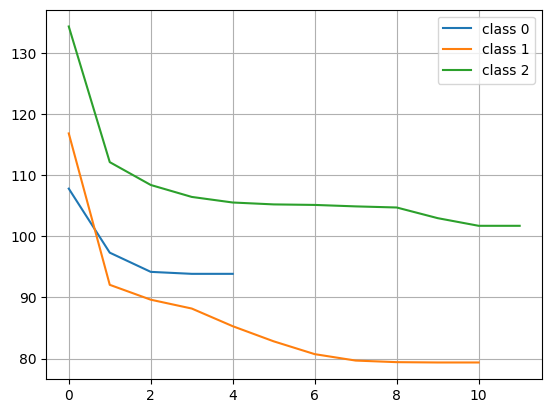

In [ ]:
for i,objv in enumerate(obj_values):
    plt.plot(objv[1:],label=f"class {i}")
    plt.grid(True)
plt.legend()

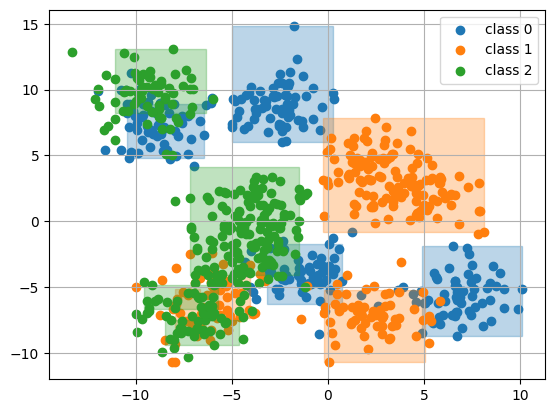

In [ ]:
clf.show_boxes(Xtr,ytr)

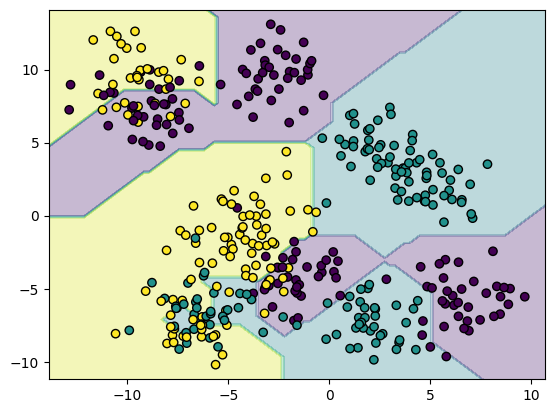

In [ ]:
disp = DecisionBoundaryDisplay.from_estimator(clf, Xte, alpha=0.3,response_method="predict")
disp.ax_.scatter(Xte[:, 0], Xte[:, 1], c=yte, edgecolor="k")

# MPCL trained using DCCP

Approach proposed in [1], but including a regularization term.

[1] I. Cunha and M.E. Valle : Training Single-Layer Morphological Perceptron Using Convex-Concave Programming, In: 2023 IEEE Latin American Conference on Computational Intelligence (LA-CCI). Recife, Brazil, 29 October - 01 November 2023.

In [ ]:
start_time_class = time.time()
clf = MPCL_DCCP(K=4,verbose=False,gamma=1)
obj_values = clf.fit(Xtr,ytr)
print("\nTime to train: %2.2f seconds." % (time.time() - start_time_class))

print("Train accuracy:",clf.score(Xtr,ytr))
print("Test accuracy:",clf.score(Xte,yte))


Time to train: 186.41 seconds.
Train accuracy: 0.82875
Test accuracy: 0.8075


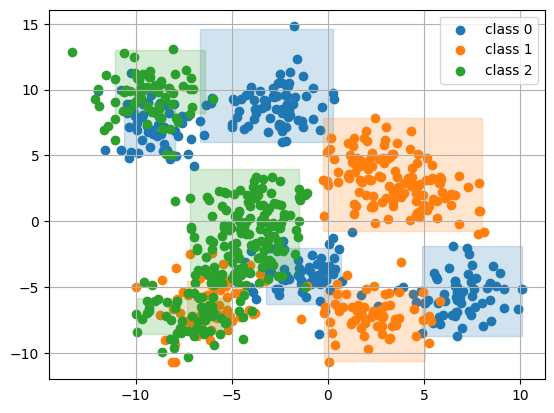

In [ ]:
clf.show_boxes(Xtr,ytr)

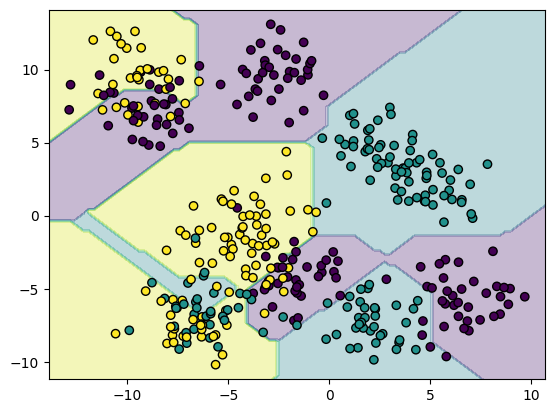

In [ ]:
disp = DecisionBoundaryDisplay.from_estimator(clf, Xte, alpha=0.3,response_method="predict")
disp.ax_.scatter(Xte[:, 0], Xte[:, 1], c=yte, edgecolor="k")

# MPCL-Adam

Training the MPCL model by minimizing the cross-entropy using a gradient-based algorithm. In this case, we used Adam optimizer.

In the following, we use kmeans++ to intialize the hyperboxes. Another alternative would be considering a random initialization or the dHpC strategy proposed by E. Zamora and H. Sossa.

In [ ]:
start_time_class = time.time()
clf = MPCL_Adam(K=4,verbose=False, boxes_init='kmeans++')
obj_values = clf.fit(Xtr,ytr)
print("\nTime to train: %2.2f seconds." % (time.time() - start_time_class))

print("Train accuracy:",clf.score(Xtr,ytr))
print("Test accuracy:",clf.score(Xte,yte))


Time to train: 13.24 seconds.
Train accuracy: 0.83625
Test accuracy: 0.8425


Train aims to minimize the loss without considering the hyperboxes valididty constraints. Thus, the weights of the trained model may fails to yield valid hyperboxes.

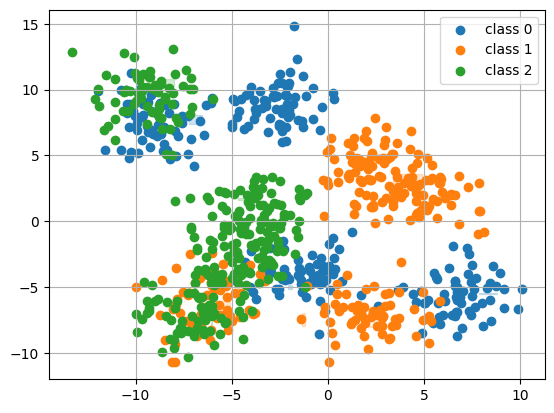

In [ ]:
clf.show_boxes(Xtr,ytr)

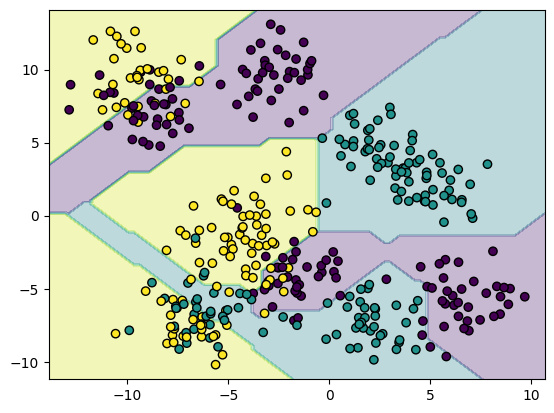

In [ ]:
disp = DecisionBoundaryDisplay.from_estimator(clf, Xte, alpha=0.3,response_method="predict")
disp.ax_.scatter(Xte[:, 0], Xte[:, 1], c=yte, edgecolor="k")

# MPCL Trained using a Greedy Algorithm

In [ ]:
start_time_class = time.time()
clf = MPCL_Greedy()
obj_values = clf.fit(Xtr,ytr)
print("\nTime to train: %2.2f seconds." % (time.time() - start_time_class))

print("Train accuracy:",clf.score(Xtr,ytr))
print("Test accuracy:",clf.score(Xte,yte))


Time to train: 0.04 seconds.
Train accuracy: 0.88375
Test accuracy: 0.7575


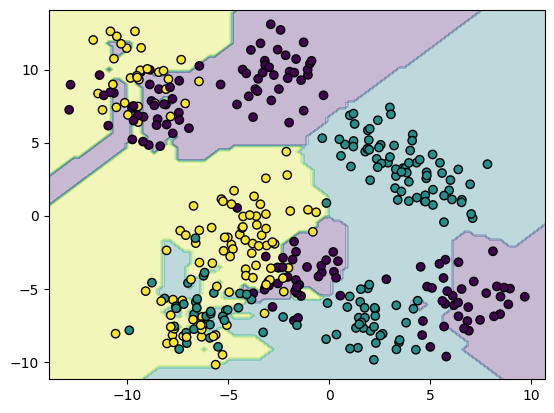

In [ ]:
disp = DecisionBoundaryDisplay.from_estimator(clf, Xte, alpha=0.3,response_method="predict")
disp.ax_.scatter(Xte[:, 0], Xte[:, 1], c=yte, edgecolor="k")